In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import os

In [2]:
# ==========================================
# FUNÇÃO GERADORA DE GRÁFICOS (ROC e PR)
# ==========================================
def plot_comparative_curves(file_paths, curve_type='ROC', target_class='normal'):
    """
    Gera um gráfico comparando múltiplos modelos limpos vs atacados.
    
    :param file_paths: Lista com os caminhos dos ficheiros .npz gerados.
    :param curve_type: 'ROC' para Curva ROC, ou 'PR' para Precision-Recall.
    :param target_class: Nome da classe a isolar (ex: 'normal' ou 'attack').
    """
    plt.figure(figsize=(10, 8))
    
    # Paleta de cores para distinguir modelos diferentes (cada modelo terá uma cor)
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e', '#8c564b']
    
    print(f"A gerar Gráfico {curve_type.upper()} para a classe '{target_class}'...\n")

    for idx, file_path in enumerate(file_paths):
        if not os.path.exists(file_path):
            print(f"Aviso: Ficheiro não encontrado -> {file_path}")
            continue
            
        # 1. Carregar os dados
        data = np.load(file_path, allow_pickle=True)
        y_true = data['y_true']
        y_prob_clean = data['y_prob_clean']
        y_prob_adv = data['y_prob_adv']
        model_name = str(data['model_name'])
        attack_name = str(data['attack_name'])
        class_names = [str(c).lower() for c in data['class_names']]
        
        # 2. Encontrar o índice da classe alvo
        try:
            class_idx = next(i for i, name in enumerate(class_names) if target_class in name)
        except StopIteration:
            print(f"Ignorado: Classe '{target_class}' não existe no ficheiro {os.path.basename(file_path)}.")
            continue
            
        # 3. Binarizar o alvo (1 se for a classe procurada, 0 caso contrário)
        y_true_binary = (y_true == class_idx).astype(int)
        
        # 4. Extrair apenas as probabilidades da classe procurada
        if len(y_prob_clean.shape) == 1 or y_prob_clean.shape[1] == 1:
            prob_c = y_prob_clean if class_idx == 1 else 1 - y_prob_clean
            prob_a = y_prob_adv if class_idx == 1 else 1 - y_prob_adv
        else:
            prob_c = y_prob_clean[:, class_idx]
            prob_a = y_prob_adv[:, class_idx]
            
        color = colors[idx % len(colors)]
        
        # ==========================================
        # CONSTRUÇÃO DA CURVA ROC
        # ==========================================
        if curve_type.upper() == 'ROC':
            # Linha Base (Clean)
            fpr_c, tpr_c, _ = roc_curve(y_true_binary, prob_c)
            auc_c = auc(fpr_c, tpr_c)
            plt.plot(fpr_c, tpr_c, color=color, linestyle='-', lw=2.5, alpha=0.9,
                     label=f"{model_name} (Clean) | AUC: {auc_c:.3f}")
            
            # Linha Sob Ataque (Adv)
            fpr_a, tpr_a, _ = roc_curve(y_true_binary, prob_a)
            auc_a = auc(fpr_a, tpr_a)
            plt.plot(fpr_a, tpr_a, color=color, linestyle='--', lw=2.5, alpha=0.8,
                     label=f"{model_name} ({attack_name}) | AUC: {auc_a:.3f}")

        # ==========================================
        # CONSTRUÇÃO DA CURVA PR (Precision-Recall)
        # ==========================================
        elif curve_type.upper() == 'PR':
            # Linha Base (Clean)
            prec_c, rec_c, _ = precision_recall_curve(y_true_binary, prob_c)
            auc_c = auc(rec_c, prec_c)
            plt.plot(rec_c, prec_c, color=color, linestyle='-', lw=2.5, alpha=0.9,
                     label=f"{model_name} (Clean) | PR-AUC: {auc_c:.3f}")
            
            # Linha Sob Ataque (Adv)
            prec_a, rec_a, _ = precision_recall_curve(y_true_binary, prob_a)
            auc_a = auc(rec_a, prec_a)
            plt.plot(rec_a, prec_a, color=color, linestyle='--', lw=2.5, alpha=0.8,
                     label=f"{model_name} ({attack_name}) | PR-AUC: {auc_a:.3f}")

    # ==========================================
    # CUSTOMIZAÇÃO VISUAL DO GRÁFICO
    # ==========================================
    if curve_type.upper() == 'ROC':
        plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':')
        plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold')
        plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12, fontweight='bold')
        plt.title(f'Curva ROC - Degradação da Classe "{target_class.capitalize()}"', fontsize=14, pad=15)
        plt.legend(loc="lower right", fontsize=10, framealpha=0.9)
        
    elif curve_type.upper() == 'PR':
        plt.xlabel('Recall (Taxa de Deteção)', fontsize=12, fontweight='bold')
        plt.ylabel('Precisão (Valor Preditivo Positivo)', fontsize=12, fontweight='bold')
        plt.title(f'Curva PR - Degradação da Classe "{target_class.capitalize()}"', fontsize=14, pad=15)
        # Na curva PR, a lenda fica melhor no canto inferior esquerdo
        plt.legend(loc="lower left", fontsize=10, framealpha=0.9)

    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.05])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    # Guardar a imagem na pasta com alta resolução
    nome_ficheiro = f"comparacao_{curve_type.lower()}_{target_class}.png"
    plt.savefig(nome_ficheiro, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Gráfico guardado com sucesso: {nome_ficheiro}")



A gerar Gráfico ROC para a classe 'normal'...



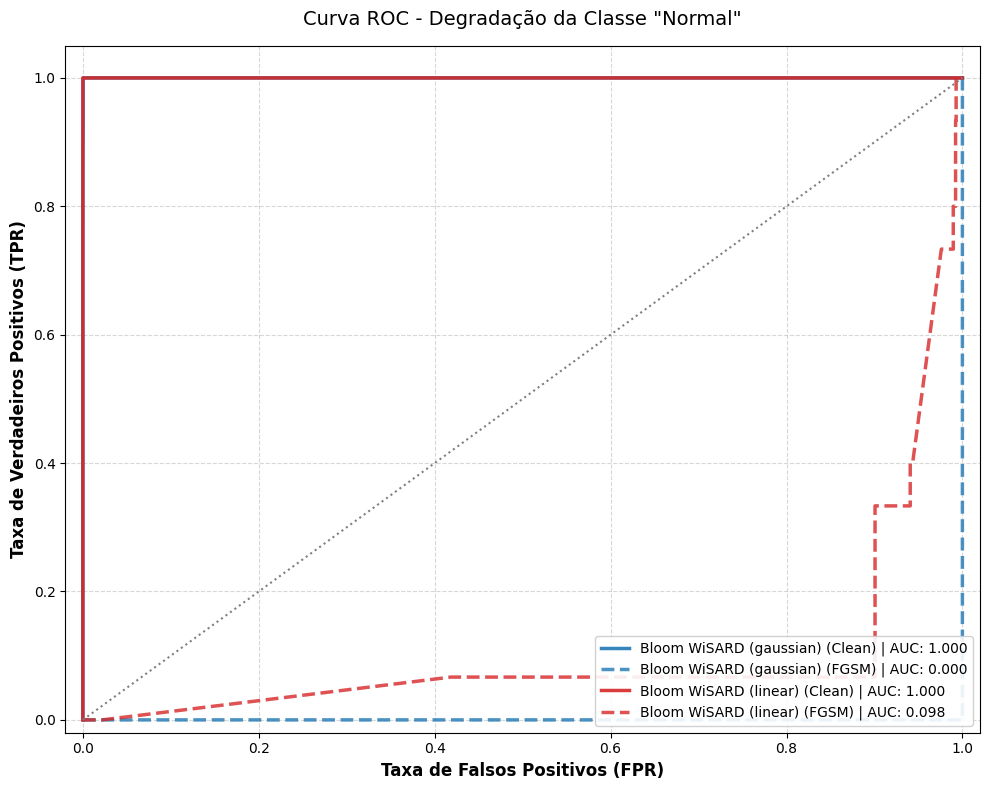

✅ Gráfico guardado com sucesso: comparacao_roc_normal.png
A gerar Gráfico PR para a classe 'normal'...



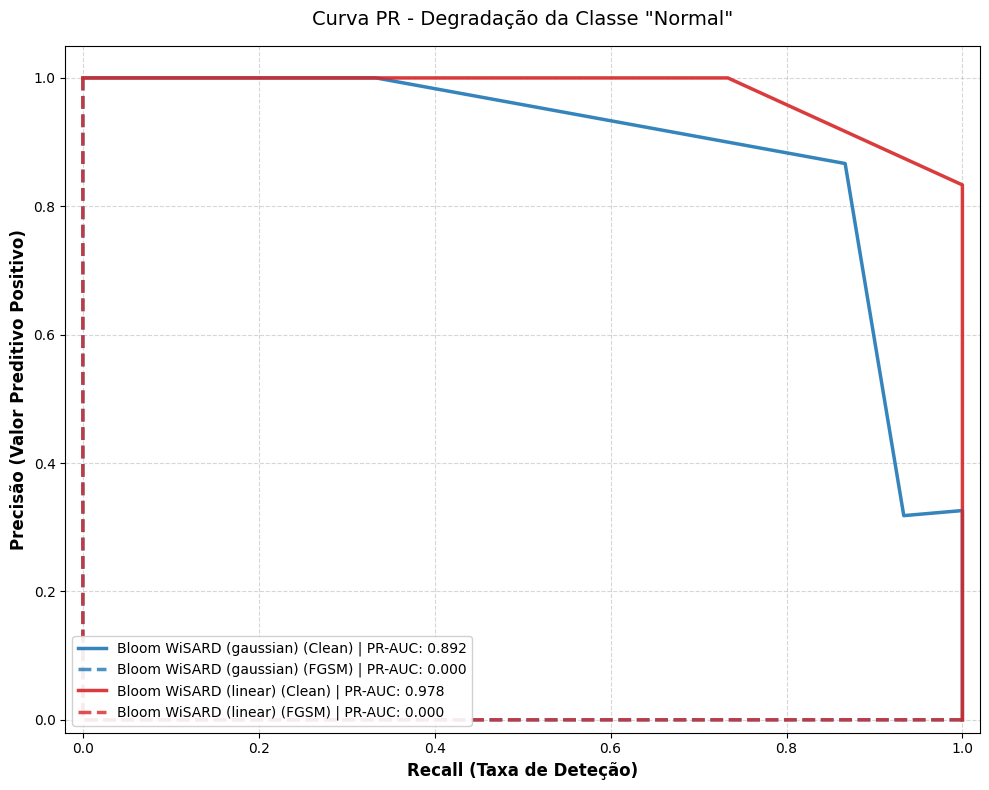

✅ Gráfico guardado com sucesso: comparacao_pr_normal.png


In [3]:

# ==========================================
# PAINEL DE EXECUÇÃO (Como utilizar a função)
# ==========================================
if __name__ == "__main__":
    # Coloque aqui os caminhos exatos dos ficheiros .npz que deseja comparar no mesmo gráfico
    # Pode misturar Decision Tree, WiSARD, SVM, desde que sejam do mesmo Dataset para ser justo.
    
    ficheiros_para_comparar = [
        # Exemplo 1: WiSARD Gaussiana sob ataque FGSM
        "curves_data/bloom_Bot-IoT_binary_gaussian_FGSM_R1_A5_B1024.npz",
        
        # Exemplo 2: WiSARD Linear sob ataque FGSM
        "curves_data/bloom_Bot-IoT_binary_linear_FGSM_R4_A10_B2048.npz"
        
        # Adicione aqui os .npz da Decision Tree ou Random Forest para criar o gráfico completo!
    ]
    
    # Gerar a Curva ROC
    plot_comparative_curves(ficheiros_para_comparar, curve_type='ROC', target_class='normal')
    
    # Gerar a Curva PR (Precision-Recall) - A mais recomendada para o seu estudo!
    plot_comparative_curves(ficheiros_para_comparar, curve_type='PR', target_class='normal')